<center><a href="https://www.nvidia.com/dli"> <img src="images/DLI_Header.png" alt="Header" style="width: 400px;"/> </a></center>

# Deploying Your Model
Now that we have a well trained model, it's time to use it. In this exercise, we'll expose new images to our model and detect the correct letters of the sign language alphabet. Let's get started!

## Objectives

* Load an already-trained model from disk
* Reformat images for a model trained on images of a different format
* Perform inference with new images, never seen by the trained model and evaluate its performance

In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.io as tv_io
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

# Loading the Model
During the previous training stage, the model parameters were stored in the directory asl_model. To perform inference, we recreate the model architecture and load the corresponding weights from this directory.

In [8]:
class MyConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p, flatten=False, img_size=None):
        kernel_size = 3
        super().__init__()

        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        ]

        if flatten:
            layers.append(nn.Flatten())

        self.model = nn.Sequential(*layers)

        if flatten and img_size:
            pool_size = img_size // 2
            self.flattened_size = out_ch * pool_size * pool_size

    def forward(self, x):
        return self.model(x)

In [9]:
model = torch.load('sample_data/L07model.pth', map_location=device, weights_only=False)
model.eval()


Sequential(
  (0): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0, inplace=False)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (1): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (2): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0, 

We can also verify if the model is on our GPU.

In [ ]:
next(model.parameters()).device

## Preparing an Image for the Model

It is now time to use the trained model to make predictions on images that were not part of the training dataset. This process is known as inference. Instead of using a predefined set of images, students are encouraged to take their own photographs of hand gestures corresponding to the American Sign Language (ASL) symbols.

For this activity, take pictures of your hands forming different ASL letters using a phone and store them in a folder (for example, data/asl_images). Once the images are collected, they can be used as input for the trained model to evaluate whether the network correctly identifies the corresponding sign.

You will likely notice that these images differ significantly from those used during training. In particular, they may have a higher resolution and will typically be in color. Recall that the images used to train the model had a resolution of 28 × 28 pixels and contained a single grayscale channel.

Therefore, before performing inference, it is essential to preprocess the images so that their shape matches the format used during training. The training dataset had the shape (27455, 28, 28, 1), which corresponds to 27,455 grayscale images of size 28 × 28 pixels. To ensure compatibility with the trained model, any new images must be converted to grayscale and resized to 28 × 28 pixels prior to making predictions.

In [24]:
CLASES = ['A','B','C','D','E','F','G','H','I','K',
          'L','M','N','O','P','Q','R','S','T','U',
          'V','W','X','Y']

IMG_WIDTH  = 28
IMG_HEIGHT = 28
IMG_CHS    = 1

transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Grayscale()
])

def prediction(image_path):
    # Load image
    img = tv_io.read_image(image_path)

    # gray scale
    if IMG_CHS == 1 and img.shape[0] == 3:
        img = transforms.Grayscale()(img)
    elif IMG_CHS == 3 and img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    img = transform(img).to(device)
    img = img.unsqueeze(0)  # (1, C, H, W)

    with torch.no_grad():
        output = model(img)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        confianza = probs[pred_idx].item() * 100

    # Top 3 predictions
    top3_vals, top3_idx = torch.topk(probs, 3)
    top3 = [(CLASES[i], v.item()*100) for i, v in zip(top3_idx, top3_vals)]

    return CLASES[pred_idx], confianza, top3

Load a picture...


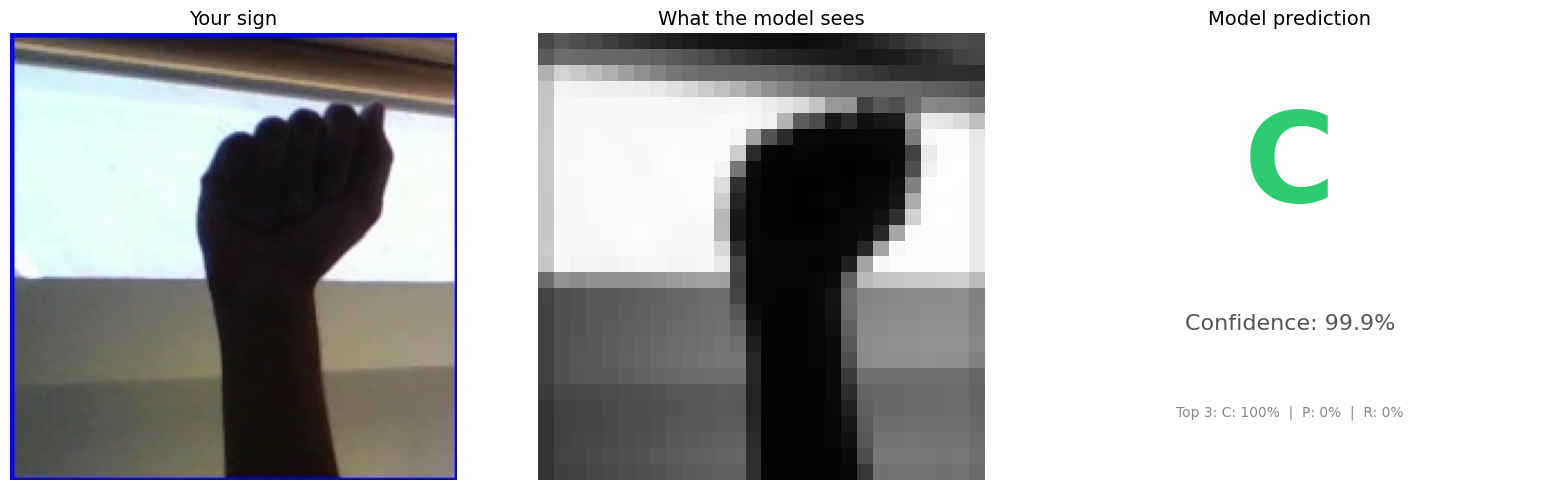


The model says it is the letter: C (99.9% confidence)


In [31]:
print('Load a picture...')

img_path = 'sample_data/A_test.jpg'

# Predict
letter, confidence, top3 = prediction(img_path)

# Load and process image to show what the model sees
img_raw = tv_io.read_image(img_path)
if IMG_CHS == 1 and img_raw.shape[0] == 3:
    img_model = transforms.Grayscale()(img_raw)
elif IMG_CHS == 3 and img_raw.shape[0] == 1:
    img_model = img_raw.repeat(3, 1, 1)
else:
    img_model = img_raw
img_model = transform(img_model).squeeze()

img_display = plt.imread(img_path)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Column 1 - Original image
ax1.imshow(img_display)
ax1.set_title('Your sign', fontsize=14)
ax1.axis('off')

# Column 2 - What the model sees
ax2.imshow(img_model, cmap='gray')
ax2.set_title('What the model sees', fontsize=14)
ax2.axis('off')

# Column 3 - Prediction
color = '#2ecc71' if confidence >= 70 else '#e67e22' if confidence >= 40 else '#e74c3c'
ax3.set_facecolor('#f8f9fa')
ax3.text(0.5, 0.70, letter, fontsize=90, fontweight='bold',
         ha='center', va='center', color=color, transform=ax3.transAxes)
ax3.text(0.5, 0.35, f'Confidence: {confidence:.1f}%', fontsize=16,
         ha='center', va='center', transform=ax3.transAxes, color='#555')
top3_txt = '  |  '.join([f'{l}: {p:.0f}%' for l, p in top3])
ax3.text(0.5, 0.15, f'Top 3: {top3_txt}', fontsize=10,
         ha='center', va='center', transform=ax3.transAxes, color='#888')
ax3.set_title('Model prediction', fontsize=14)
ax3.axis('off')

plt.tight_layout()
plt.savefig('resultado.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nThe model says it is the letter: {letter} ({confidence:.1f}% confidence)')